# ENPM673 Project 1

In [ ]:
"""
@file pkoli_project1.ipynb
@author Pranav Jagdish Koli
@brief The .ipynb file for Project 1.
@date 02-25-2026
@copyright Copyright (c) 2026
"""

'\n@file pkoli_project1.ipynb\n@author Pranav Jagdish Koli\n@brief The .ipynb file for Project 1.\n@date 02-25-2026\n@copyright Copyright (c) 2026\n'

## Step 0.1: Import the video file from *Google Drive*

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
path_to_folder = "Colab Notebooks/"
%cd /content/drive/My\ Drive/{path_to_folder}

/content/drive/My Drive/Colab Notebooks


## Step 0.2: Importing Dependencies

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Read the video and setting up boundaries for Yellow color ball

In [ ]:
video_path = 'yellow_ball_up_and_down.mp4'
start_frame = 191
end_frame = 292

# HSV color boundaries for the yellow ball
lower_limit_yellow = np.array([20, 100, 100])
upper_limit_yellow = np.array([30, 255, 255])

## Step 2 & 3: Loop over video frames 191 to 292 and extract the pixels corresponding to the moving yellow ball and calculate the centroid

In [ ]:
cap = cv2.VideoCapture(video_path)
centroids = []
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if start_frame <= frame_idx <= end_frame:
        # Step 2: Convert to HSV and Mask
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower_limit_yellow, upper_limit_yellow)

        # Step 3: Calculate Centroid
        y_coords, x_coords = np.where(mask > 0)
        if len(x_coords) > 0:
            h, w = frame.shape[:2]
            cx = np.mean(x_coords)

            cy = h - np.mean(y_coords)
            centroids.append([cx, cy])

    frame_idx += 1

cap.release()

## For each frame, the centroid of the extracted pixels is stored as a dataset

In [ ]:
data = np.array(centroids)
x = data[:, 0]
y = data[:, 1]
print(f"Dataset created with {len(data)} points.")

Dataset created with 60 points.


## Step 4: *Standard Least Squares* and *Total Least Squares* to fit a line through the centroids

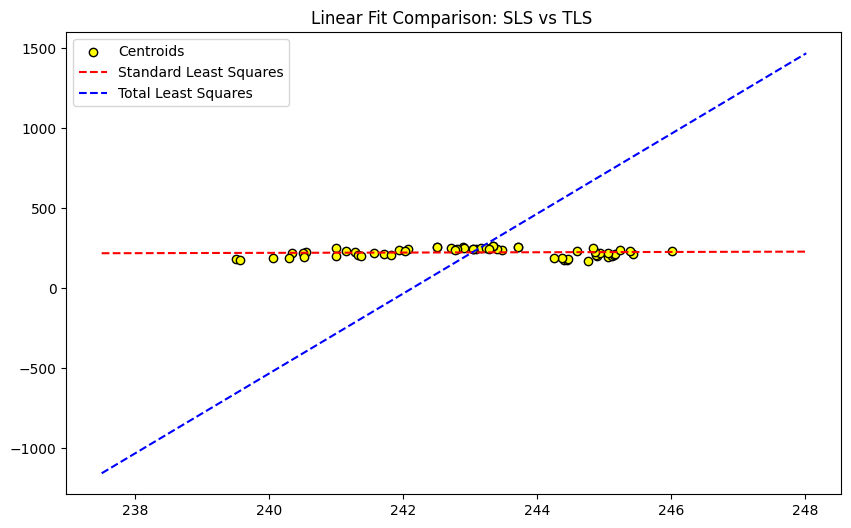

In [ ]:
# Standard Least Squares (y = mx + b)
A_sls = np.vstack([x, np.ones(len(x))]).T
m_sls, b_sls = np.linalg.inv(A_sls.T @ A_sls) @ A_sls.T @ y

# Total Least Squares (ax + by = d)
x_mean, y_mean = np.mean(x), np.mean(y)
centered = np.vstack([x - x_mean, y - y_mean]).T

# SVD finds the direction of least variance (ie. the normal to the line)
U, S, Vt = np.linalg.svd(centered)
a_tls, b_tls = Vt[-1]
d_tls = a_tls * x_mean + b_tls * y_mean

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='yellow', edgecolors='k', label='Centroids')
x_plot = np.linspace(min(x)-2, max(x)+2, 100)

# Plotting SLS: y = mx + b
plt.plot(x_plot, m_sls * x_plot + b_sls, 'r--', label='Standard Least Squares')

# Plotting TLS: y = (d - ax) / b
plt.plot(x_plot, (d_tls - a_tls * x_plot) / b_tls, 'b--', label='Total Least Squares')
plt.legend()
plt.title("Linear Fit Comparison: SLS vs TLS ")
plt.show()

In this scenario, the Total Least Squares provides an incorrect vertical line because the variance in y pixels is a lot more than that of x pixels. Mathematically the equation for Total Least Squares is correct, just due to the high difference in variance, it is representated incorrectly.

Q1. Is it better to use Total Least Squares or Standard Least Squares for fitting this dataset?

Answer: The ball is mostly moving in upwards direction so there is less moment of the ball in x axis pertaining to less noise. Standard Least Squares can easily handle the noise for y axis. So its better to use Standard Least Squares over Total Least Squares for this dataset. If the noise was present for both the axes, Total Least Squares would be the ideal choice.

## Step 5: Using both *Standard Least Squares* and *RANSAC* to fit a quadratic curve

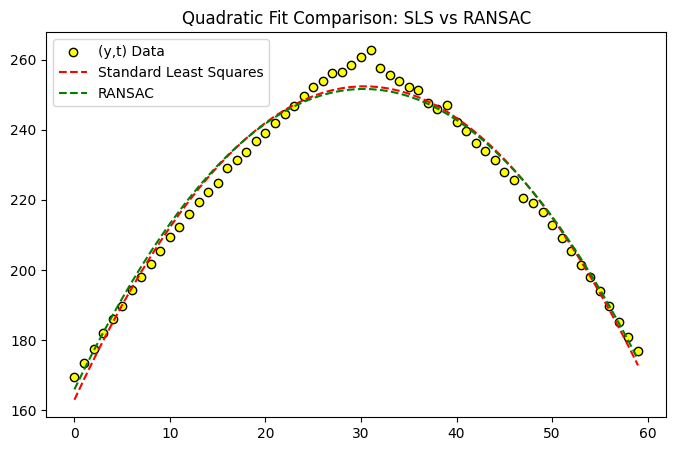

In [ ]:
# Step 5: Curve fitting through y-values
# y = at^2 + bt + c
t = np.arange(len(y))
T_mat = np.vstack([t**2, t, np.ones(len(t))]).T

# Standard LS Parabola
p_sls = np.linalg.inv(T_mat.T @ T_mat) @ T_mat.T @ y

# RANSAC Parabola
best_inliers = 0
p_ransac = None
for _ in range(2000):
    sample = np.random.choice(len(t), 3, replace=False)
    try:
        p_guess = np.linalg.solve(T_mat[sample], y[sample])
        res = np.abs(y - (T_mat @ p_guess))
        inliers = np.sum(res < 5.0) # With 5-pixel tolerance
        if inliers > best_inliers:
            best_inliers = inliers
            p_ransac = p_guess
    except: continue

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(t, y, color='yellow', edgecolors='k', label='(y,t) Data')
plt.plot(t, T_mat @ p_sls, 'r--', label='Standard Least Squares')
plt.plot(t, T_mat @ p_ransac, 'g--', label='RANSAC')
plt.title("Quadratic Fit Comparison: SLS vs RANSAC")
plt.legend()
plt.show()

Q2. Is there any reason not to use Total Least Squares?

Answer: Total Lease Squares is used when both the axes have noise or error. In this case, the curve is fitted as Y (pixels) vs Time (t). Since time is an exact quantity (ie. it doesn't have any noise), there's no need for using Total Least Squares approach.

Q3. Is there any major advantage of using RANSAC over LS on this dataset?

Answer: For this dataset, Least Squares is already sufficient as the dataset is cleaned. If there were outliers present on this dataset, RANSAC would be the more efficient method.

## Step 6: Finding the corresponding Y value for X=59.2

In [ ]:
# Step 6: Find y for x = 59.2
x = 59.2
y_sls = m_sls * x + b_sls
y_tls = (d_tls - a_tls * x) / b_tls

print(f"Results for x = {x}:")
print(f"Standard Least Squares, y = {y_sls:.4f}")
print(f"Total Least Squares, y = {y_tls:.4f}")

Results for x = 59.2:
Standard Least Squares, y = 49.7409
Total Least Squares, y = -45676.3285
